#クラスタリング

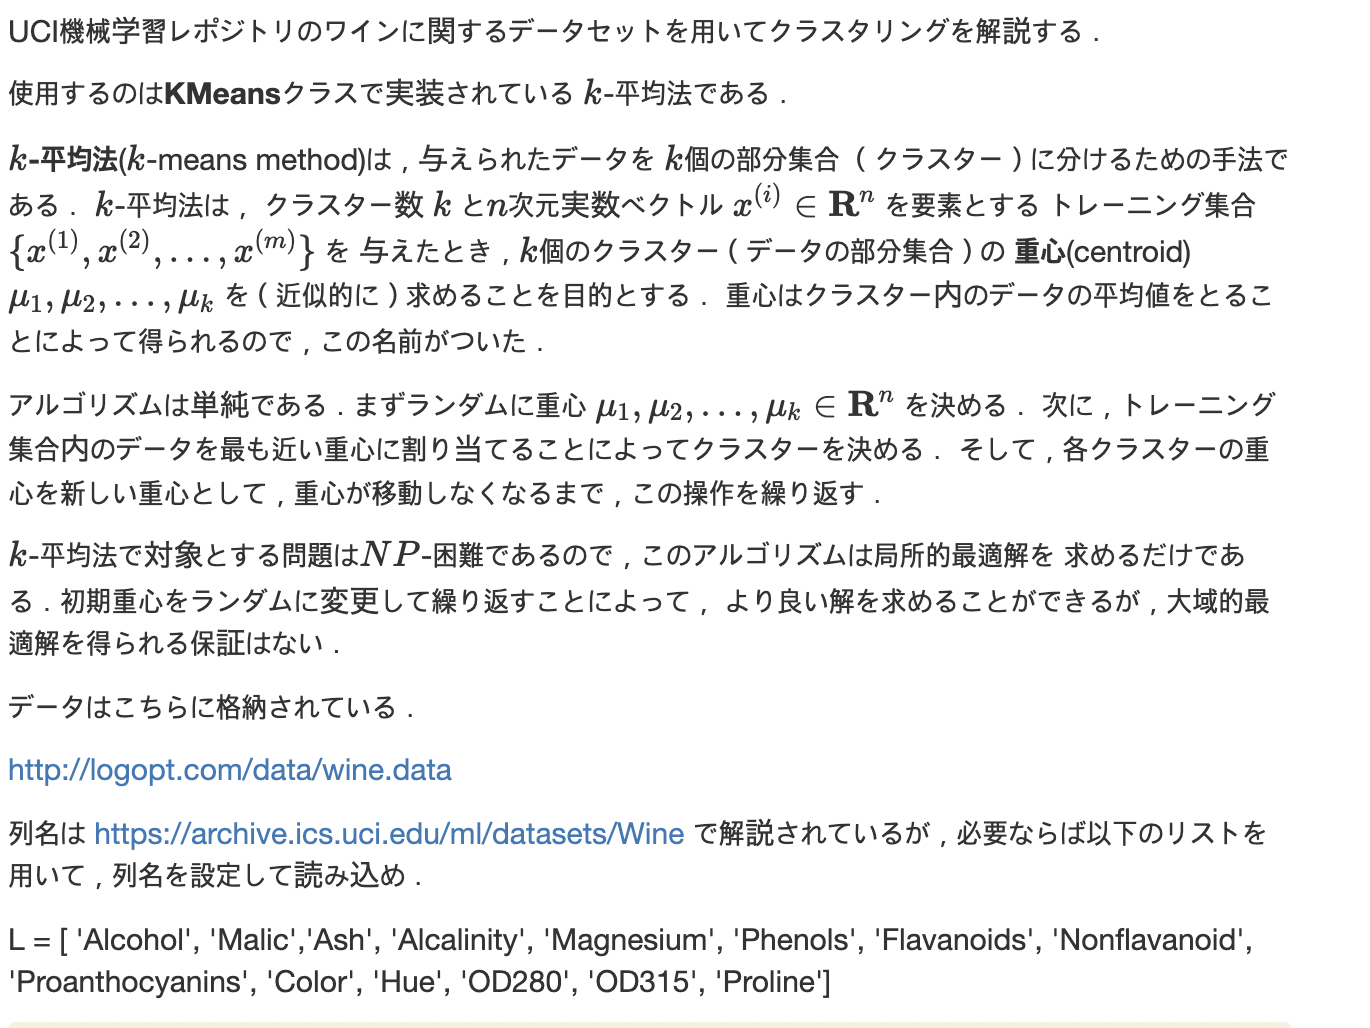

In [1]:
# クラスタリング - ターゲットなしの,特徴ベクトルだけ与えて機械学習
# 全て独立変数

import pandas as pd
L = [ 'Alcohol', 'Malic','Ash', 'Alcalinity', 'Magnesium', 'Phenols', 'Flavanoids', 'Nonflavanoid',
     'Proanthocyanins', 'Color', 'Hue', 'OD280', 'OD315', 'Proline']
wine = pd.read_csv('http://logopt.com/data/wine.data',names=L)
wine.head()

#ワインの何種類かに分類をする

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoid,Proanthocyanins,Color,Hue,OD280,OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [2]:
from sklearn.cluster import KMeans  # クラスをインポート
kmeans = KMeans(n_clusters=4)       # インスタンス生成, (n_clusters=分けたい数)
kmeans.fit(wine)                    # 訓練

KMeans(n_clusters=4)

In [3]:
wine['label'] = kmeans.labels_ #kmeans.labels_の中に4つ(0~3までの数字)に分けたワインが入る
wine.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoid,Proanthocyanins,Color,Hue,OD280,OD315,Proline,label
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,3


# パラメータKの適正化 （エルボー法）

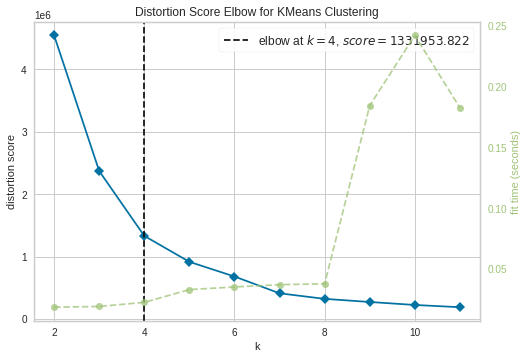

In [4]:
# ４つでいいのか確認
from yellowbrick.cluster import KElbowVisualizer

visualizer = KElbowVisualizer(kmeans, k=(2,12)) #k=(2,12) - 2から12まで変える
visualizer.fit(wine)
visualizer.show();

#曲がるあたりがいい,クラスターの数を減らすと過剰適合になる,kが伸びると計算時間が伸びる

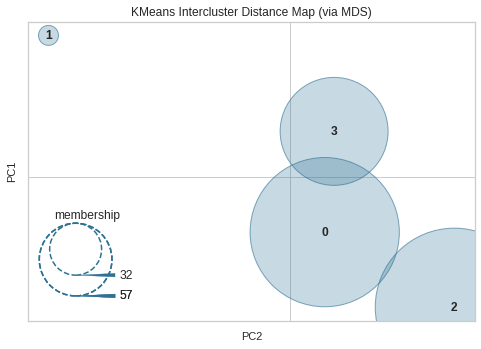

In [5]:
# 可視化
from yellowbrick.cluster import InterclusterDistance

kmeans = KMeans(n_clusters=4) #(n_clusters=5)はあまりよくない 
visualizer = InterclusterDistance(kmeans)
visualizer.fit(wine)       
visualizer.show(); 

#図の２はほかとよく分離されている
# PCは主成分,2つのクラスターに分ける

In [6]:
# 問題（アヤメ）
# irisのデータセットの各データを kk-平均法を用いて3つのクラスターに分けよ．
